# Audio Processing - Automatic Music Transcription (AMT)

Aim: Design a polyphonic, single-instrument, note-level AMT pipeline for converting audio recording (.wav) into the MIDI dict format which can be passed into compare_performance_ED() in compare_MIDI.py.
- audio → pitch + onset + offset
- Although only one instrument is present in one recording, piano performances are inherently polyphonic because multiple notes may sound simultaneously (e.g., block chords or overlapping sustained notes). 
 
General sturcture of AMT pipeline:
- Step 1: read in the .wav audio file
- Step 2: preprocessing, prepare audio for the model
    - Time-frequency representation (Spectrogram) - Fourier Analysis of Signals: STFT, CQT
    - Pitch/Note/Onset estimation (Multi-Pitch Estimation (MPE) for Polyphonic)
- Step 3: AMT model (CNN/LSTM/Transformer)
- Step 4: postprocessing, convert the model output to the MIDI dict format which can be passed into compare_performance_ED()

---

**Model**

consider using Basic Pitch: it is a Python library for AMT, using lightweight neural network developed by Spotify's Audio Intelligence Lab.: https://arxiv.org/pdf/2203.09893

https://github.com/spotify/basic-pitch

@inproceedings{2022_BittnerBRME_LightweightNoteTranscription_ICASSP,
  author= {Bittner, Rachel M. and Bosch, Juan Jos\'e and Rubinstein, David and Meseguer-Brocal, Gabriel and Ewert, Sebastian},
  title= {A Lightweight Instrument-Agnostic Model for Polyphonic Note Transcription and Multipitch Estimation},
  booktitle= {Proceedings of the IEEE International Conference on Acoustics, Speech, and Signal Processing (ICASSP)},
  address= {Singapore},
  year= 2022,
}

---

**Dataset**

https://yonghyunk1m.github.io/PianoVAM/ 

https://huggingface.co/datasets/PianoVAM/PianoVAM_v1 

The PianoVAM dataset was recorded using a Disklavier piano, capturing audio and MIDI from amateur pianists during their **daily practice sessions**, which are closer to the intended application domain (music practice & music education). This dataset includes videos, audio, MIDI, hand landmarks, fingering labels, and rich metadata, but the Github repo is still under construction.

- A Disklavier records the actual
  key strikes as MIDI, reflects what was really played, not a manual transcription of the audio. so it can be used as the ground truth (reference).
- The audio file can be processed with Basic Pitch to get response MIDI.

The dataset has proper official `train`, `valid`, `test`, `ext-train`, and `special-purpose` splits, which can prevent data leakage during the optimising post-processing part.
- `train` for exploratory error analysis and designing candidate rules;
- `valid` for selecting thresholds and post-processing settings;
- `test` only once after the final configuration has been fixed.
- The special splits can later be used as optional robustness tests.

it may be helpful for improving the pretrained model, i.e. feedback-oriented post-processing:
- fit the pre-trained model on the PianoVAM dataset, evaluate: AMT metrics (precision、recall、F1), Feedback analysis (Pitch feedback accuracy, Missing-note feedback precision, Extra-note feedback precision, Chord feedback accuracy, Timing feedback accuracy, Duration feedback accuracy...)

Limitation: PianoVAM's own authors caution that, because all recordings are informal practice sessions, the dataset is not suitable
for *performance-vs-score* comparison research. 
(Note that for the Phase 1 alignment evaluation is done on nASAP dataset). Here, PianoVAM is only used
for:
1. **analysing AMT transcription accuracy** -- Basic Pitch's transcribed MIDI vs PianoVAM's Disklavier ground-truth MIDI.
2. **optimising Post-processing part feedback-orientedly** -- feeding both the ground-truth MIDI and the AMT-transcribed MIDI through the existing `compare_performance_ED()` pipeline (with the ground truth as "reference" and the AMT output as "response"), to see how AMT transcription noise alone propagates into event-level feedback.


@inproceedings{kim2025pianovam,
  title={PianoVAM: A Multimodal Piano Performance Dataset},
  author={Yonghyun Kim and Junhyung Park and Joonhyung Bae and Taegyun Kwon and Kirak Kim and Alexander Lerch and Juhan Nam},
  booktitle={Proceedings of the 26th International Society for Music Information Retrieval Conference (ISMIR)},
  year={2025},
  address={Daejeon, South Korea}
}

---

In this notebook:

1. The first goal is to make the full workflow run correctly on one selected sample (the simplest case).
    - Use the pretrained Basic Pitch model to transcribe the audio.
    - Convert the predicted MIDI into the dictionary format used by `compare_performance_ED()`.
    - Compare the prediction with the PianoVAM performance MIDI.
2. Then apply to all recordings for quantitative evaluation. 
    - Visualise and evaluate the transcription.
    - Inspect how AMT errors propagate into the existing feedback pipeline, find out how to improve the results (maybe implement my own postprocessing)

For the Basic Pitch:
- The input to Basic Pitch is the PianoVAM `.wav` audio recording.
- Basic Pitch returns:
    - `model_output`: raw model inference output (frame-level onset, note and pitch-contour activations);
    - `predicted_midi`: transcribed MIDI data derived from the model_output (a `pretty_midi.PrettyMIDI` object produced by Basic Pitch post-processing);
    - `note_events`: a list of note events derived from the model_output (decoded note-level events containing onset, offset, pitch, amplitude and optional pitch-bend information).

For this baseline, the official pretrained model and its built-in preprocessing and post-processing are used without training or fine-tuning.

The ground truth for AMT evaluation is the PianoVAM performance MIDI recorded by the Disklavier (digital piano) for the same recording, not a musical score MIDI. The TSV file contains pre-processed label data derived from the MIDI files for easier parsing.

## I. Download PianoVAM dataset (MIDI and audio only), and run Basic Pitch with one selected sample to make sure the whole process works.

Download and inspect the dataset first, only download necessary files, video and hand-skeleton files are excluded because they are not needed for the transcription task.

In [1]:
from pathlib import Path
from huggingface_hub import snapshot_download

PIANOVAM_ROOT = Path("data/PianoVAM_v1")

def download_pianovam(local_dir):
    """
    Download parts of PianoVAM needed for audio transcription and
    downstream feedback evaluation.
    """
    local_dir = Path(local_dir)
    snapshot_download(
        repo_id="PianoVAM/PianoVAM_v1",
        repo_type="dataset",
        local_dir=local_dir,
        allow_patterns=[
            "Audio/*",
            "MIDI/*",
            "TSV/*",
            "metadata.json"
        ],
    )
    return local_dir

PIANOVAM_ROOT = download_pianovam(PIANOVAM_ROOT)

audio_files = sorted((PIANOVAM_ROOT / "Audio").glob("*.wav"))
midi_files = sorted((PIANOVAM_ROOT / "MIDI").glob("*.mid"))
tsv_files = sorted((PIANOVAM_ROOT / "TSV").glob("*.tsv"))

print(f"PianoVAM root: {PIANOVAM_ROOT}")
print(f"Audio files: {len(audio_files)}")
print(f"MIDI files: {len(midi_files)}")
print(f"TSV files: {len(tsv_files)}")
print(f"Metadata exists: {(PIANOVAM_ROOT / 'metadata.json').exists()}")

if len(audio_files) == 0:
    raise FileNotFoundError("No audio files found.")

if len(midi_files) == 0:
    raise FileNotFoundError("No MIDI files found.")

if len(tsv_files) == 0:
    raise FileNotFoundError("No TSV files found.")

if not (PIANOVAM_ROOT / "metadata.json").exists():
    raise FileNotFoundError("metadata.json was not downloaded.")

/Users/jz7125/compareMusic/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 322 files: 100%|██████████| 322/322 [00:00<00:00, 1473.47it/s]

PianoVAM root: data/PianoVAM_v1
Audio files: 107
MIDI files: 107
TSV files: 107
Metadata exists: True


inspect the metadata first

In [2]:
import json
import pandas as pd

METADATA_PATH = PIANOVAM_ROOT / "metadata.json"

with open(METADATA_PATH, "r") as file:
    metadata = json.load(file)

metadata_df = (
    pd.DataFrame.from_dict(
        metadata,
        orient="index"
    )
    .reset_index(names="sample_id")
)

print(metadata_df.shape)

metadata_df.head()

(107, 22)


,sample_id,record_time,split,composer,piece,performance_method,performance_type,duration,P1_name,P1_gender,...,P1_musicmajor,P2_name,P2_gender,P2_age,P2_skill,P2_musicmajor,Point_LT,Point_RT,Point_RB,Point_LB
0,0,2024-02-14_19-10-09,train,E. Grieg,Piano Concerto,Solo,DailyPractice,0 days 00:12:25.493.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"121, 355","1839, 345","1839, 558","120, 564"
1,1,2024-02-14_19-44-26,train,N. Kapustin,Concert Etude No.6,Solo,DailyPractice,0 days 00:08:13.653.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"120, 356","1842, 343","1842, 559","122, 565"
2,2,2024-02-14_19-55-17,test,C. Saint-Saens,Piano Concerto No.2,Solo,DailyPractice,0 days 00:12:35.285.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"120, 357","1842, 345","1843, 560","121, 566"
3,3,2024-02-14_20-10-08,test,N. Kapustin,Concert Etude No.7,Solo,DailyPractice,0 days 00:21:39.840.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"120, 356","1843, 344","1843, 559","121, 566"
4,4,2024-02-14_20-37-55,train,M. Ravel,Piano Concerto in G Major,Solo,DailyPractice,0 days 00:18:21.205.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"120, 356","1842, 344","1842, 559","121, 565"


want to choose the shortest one as the first sample for evaluation

In [3]:
metadata_df["duration_seconds"] = pd.to_timedelta(
    metadata_df["duration"]
).dt.total_seconds()

candidate_samples = metadata_df[
    (metadata_df["performance_method"] == "Solo")
    & (metadata_df["split"].isin(["train", "valid", "test"]))
].copy()

candidate_samples = candidate_samples.sort_values("duration_seconds")

In [4]:
candidate_samples[
    [
        "sample_id",
        "record_time",
        "composer",
        "piece",
        "duration",
        "P1_skill",
        "split",
    ]
].head(10)

,sample_id,record_time,composer,piece,duration,P1_skill,split
28,28,2024-02-17_21-37-57,M. Ravel,Piano Concerto in G Major,0 days 00:00:22.400.000000,Advanced,train
36,36,2024-03-04_03-46-36,N/A [Mozart],"N/A [Piano Sonata No. 16 in C Major, K.545 (1s...",0 days 00:00:22.805.000000,Advanced,train
50,50,2024-03-27_11-49-04,N. Kapustin,Piano Sonata No.2,0 days 00:01:26.571.000000,Advanced,train
64,64,2024-09-02_18-25-31,M. Clementi,Sonatine Op.36,0 days 00:02:08.336.000000,Advanced,train
51,51,2024-04-08_22-49-18,N. Kapustin,Piano Sonata No.2,0 days 00:02:57.621.000000,Advanced,train
29,29,2024-02-17_21-44-37,Yiruma,Kiss The Rain,0 days 00:02:57.835.000000,Beginner,test
39,39,2024-03-04_04-32-11,N/A [Yonghyun],N/A [Improvisation],0 days 00:02:58.752.000000,Advanced,train
65,65,2024-09-02_18-29-40,W. A. Mozart,Sonata K.545,0 days 00:03:27.783.000000,Advanced,train
18,18,2024-02-15_21-57-38,E. Grieg,Piano Concerto,0 days 00:03:33.717.000000,Advanced,train
54,54,2024-04-08_23-42-45,Harold Arlen (arr. Rupert Austin),Over The Rainbow,0 days 00:04:27.115.000000,Advanced,train


In [5]:
SELECTED_SAMPLE_ID = "28"
sample_rows = metadata_df[metadata_df["sample_id"] == SELECTED_SAMPLE_ID]

sample = sample_rows.iloc[0]
file_stem = str(sample["record_time"])

AUDIO_PATH = PIANOVAM_ROOT / "Audio" / f"{file_stem}.wav"
MIDI_PATH = PIANOVAM_ROOT / "MIDI" / f"{file_stem}.mid"
TSV_PATH = PIANOVAM_ROOT / "TSV" / f"{file_stem}.tsv"

for path in [AUDIO_PATH, MIDI_PATH, TSV_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

print("Selected sample:", SELECTED_SAMPLE_ID)
print("Audio:", AUDIO_PATH)
print("MIDI:", MIDI_PATH)
print("TSV:", TSV_PATH)


Selected sample: 28
Audio: data/PianoVAM_v1/Audio/2024-02-17_21-37-57.wav
MIDI: data/PianoVAM_v1/MIDI/2024-02-17_21-37-57.mid
TSV: data/PianoVAM_v1/TSV/2024-02-17_21-37-57.tsv


inspect ground truth MIDI and the tsv file

In [16]:
tsv_df = pd.read_csv(TSV_PATH, sep="\t")
print("\nTSV columns:")
print(list(tsv_df.columns))

tsv_df.head()


TSV columns:
['# onset', 'key_offset', 'frame_offset', 'note', 'velocity']


,# onset,key_offset,frame_offset,note,velocity
0,3.112500,3.230208,3.231250,40,15
1,3.231250,3.297917,5.600000,40,3
2,3.980208,4.292708,4.784375,56,37
3,4.001042,4.252083,4.787500,64,30
4,4.784375,5.075000,6.412500,56,24


In [ ]:
def load_ground_truth_notes_from_tsv(tsv_df):
    """
    Load PianoVAM ground-truth notes from TSV.

    frame_offset is used as the note offset because it represents when the
    sound ends after accounting for sustain-pedal effects. This is more
    appropriate for evaluating an audio transcription model such as
    Basic Pitch than key_offset, which only represents key release time.
    """
    notes = []

    for _, row in tsv_df.iterrows():
        onset = float(row["# onset"])
        key_offset = float(row["key_offset"])
        frame_offset = float(row["frame_offset"])

        if key_offset < onset:
            raise ValueError(
                f"key_offset {key_offset} is before onset {onset}"
            )

        if frame_offset < onset:
            raise ValueError(
                f"frame_offset {frame_offset} is before onset {onset}"
            )

        notes.append({
            "pitch": int(row["note"]),
            "onset": onset,
            "key_offset": key_offset,
            "frame_offset": frame_offset,
            "key_duration": key_offset - onset,
            "audible_duration": frame_offset - onset,
            "velocity": int(row["velocity"]),
        })

    notes.sort(key=lambda note: (note["onset"], note["pitch"]))
    return notes

ground_truth_notes = load_ground_truth_notes_from_tsv(tsv_df)

print("Ground-truth notes:", len(ground_truth_notes))
print("First five notes:")

for note in ground_truth_notes[:5]:
    print(note)

Ground-truth notes: 42
First five notes:
{'pitch': 40, 'onset': 3.1125, 'key_offset': 3.230208, 'frame_offset': 3.23125, 'key_duration': 0.11770800000000037, 'audible_duration': 0.11875000000000036, 'velocity': 15}
{'pitch': 40, 'onset': 3.23125, 'key_offset': 3.297917, 'frame_offset': 5.6, 'key_duration': 0.06666699999999981, 'audible_duration': 2.3687499999999995, 'velocity': 3}
{'pitch': 56, 'onset': 3.980208, 'key_offset': 4.292708, 'frame_offset': 4.784375, 'key_duration': 0.3125, 'audible_duration': 0.8041669999999996, 'velocity': 37}
{'pitch': 64, 'onset': 4.001042, 'key_offset': 4.252083, 'frame_offset': 4.7875, 'key_duration': 0.25104099999999985, 'audible_duration': 0.7864579999999997, 'velocity': 30}
{'pitch': 56, 'onset': 4.784375, 'key_offset': 5.075, 'frame_offset': 6.4125, 'key_duration': 0.29062500000000036, 'audible_duration': 1.6281249999999998, 'velocity': 24}


In [8]:
tsv_df["key_duration"] = (tsv_df["key_offset"] - tsv_df["# onset"])
tsv_df["audible_duration"] = (tsv_df["frame_offset"] - tsv_df["# onset"])
tsv_df["pedal_extension"] = (tsv_df["frame_offset"] - tsv_df["key_offset"])

print(tsv_df[["# onset", "note", "key_duration", "audible_duration", "pedal_extension"]].head(10))

    # onset  note  key_duration  audible_duration  pedal_extension
0  3.112500    40      0.117708          0.118750         0.001042
1  3.231250    40      0.066667          2.368750         2.302083
2  3.980208    56      0.312500          0.804167         0.491667
3  4.001042    64      0.251041          0.786458         0.535417
4  4.784375    56      0.290625          1.628125         1.337500
5  4.787500    64      0.191667          1.631250         1.439583
6  5.600000    40      0.183333          2.664583         2.481250
7  6.412500    56      0.397917          0.840625         0.442708
8  6.418750    64      0.416667          0.835417         0.418750
9  7.253125    56      0.292708          1.901042         1.608334


The TSV annotations additionally provide the frame offset information, which represents the end of the audible note (a note will still be hearable after note-off action if sustain pedal is used).

Since Basic Pitch transcribes from audio rather than key presses, the frame offset may provide a more suitable reference when analysing note durations.

try Basic Pitch on the selected sample

In [ ]:
from basic_pitch.inference import predict
from basic_pitch import ICASSP_2022_MODEL_PATH

OUTPUT_DIR = Path("outputs/phase2_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ONSET_THRESHOLD = 0.5
FRAME_THRESHOLD = 0.3
MINIMUM_NOTE_LENGTH = 127.7

# with default parameters
model_output, predicted_midi, note_events = predict(
    str(AUDIO_PATH),
    model_or_model_path=ICASSP_2022_MODEL_PATH,
    onset_threshold=ONSET_THRESHOLD,
    frame_threshold=FRAME_THRESHOLD,
    minimum_note_length=MINIMUM_NOTE_LENGTH,
    multiple_pitch_bends=False,
)

prediction_path = OUTPUT_DIR / f"{AUDIO_PATH.stem}_basic_pitch.mid"
predicted_midi.write(str(prediction_path))

In [10]:
import importlib.metadata

print("basic-pitch version:",
      importlib.metadata.version("basic-pitch"))
print("model path:", ICASSP_2022_MODEL_PATH)
print("Output directory:", OUTPUT_DIR.resolve())
print("model_output type:", type(model_output))
print("predicted MIDI type:", type(predicted_midi))
print("note_events type:", type(note_events))
print("Predicted note events:", len(note_events))
print("Saved prediction:", prediction_path)

basic-pitch version: 0.4.0
model path: /Users/jz7125/compareMusic/.venv/lib/python3.11/site-packages/basic_pitch/saved_models/icassp_2022/nmp.mlpackage
Output directory: /Users/jz7125/compareMusic/notebooks/outputs/phase2_baseline
model_output type: <class 'dict'>
predicted MIDI type: <class 'pretty_midi.pretty_midi.PrettyMIDI'>
note_events type: <class 'list'>
Predicted note events: 63
Saved prediction: outputs/phase2_baseline/2024-02-17_21-37-57_basic_pitch.mid


In [ ]:
def convert_predicted_midi_to_notes(predicted_midi):
    """
    Convert the MIDI produced by Basic Pitch into a sorted list of
    predicted note events.
    """
    notes = []

    for instrument in predicted_midi.instruments:
        if not instrument.is_drum:
            for midi_note in instrument.notes:
                note = {
                    "pitch": int(midi_note.pitch),
                    "onset": float(midi_note.start),
                    "offset": float(midi_note.end),
                    "duration": float(midi_note.end - midi_note.start),
                    "velocity": int(midi_note.velocity),
                }
                notes.append(note)

    notes.sort(key=lambda note: (note["onset"], note["pitch"]))

    return notes

predicted_notes = convert_predicted_midi_to_notes(predicted_midi)

print("Predicted notes:", len(predicted_notes))
print("Ground-truth notes:", len(ground_truth_notes))

Predicted notes: 63
Ground-truth notes: 42


sanity checks


In [ ]:
ONSET_TOLERANCE = 0.05

predicted_first_onset = min(note["onset"] for note in predicted_notes)
predicted_last_onset = max(note["onset"] for note in predicted_notes)

ground_truth_first_onset = min(
    note["onset"] for note in ground_truth_notes
)
ground_truth_last_key_offset = max(
    note["key_offset"] for note in ground_truth_notes
)
ground_truth_last_frame_offset = max(
    note["frame_offset"] for note in ground_truth_notes
)

predicted_before_audible_region = [
    note for note in predicted_notes
    if note["onset"] < ground_truth_first_onset - ONSET_TOLERANCE
]

predicted_after_key_region = [
    note for note in predicted_notes
    if note["onset"] > ground_truth_last_key_offset + ONSET_TOLERANCE
]

predicted_after_audible_region = [
    note for note in predicted_notes
    if note["onset"] > ground_truth_last_frame_offset + ONSET_TOLERANCE
]

print("Predicted note count:", len(predicted_notes))
print("Ground-truth note count:", len(ground_truth_notes))
print(f"Predicted onset range: {predicted_first_onset} to {predicted_last_onset}")
print(f"Ground-truth audible range: {ground_truth_first_onset} to {ground_truth_last_frame_offset}")
print(f"Predictions before first ground-truth onset: {len(predicted_before_audible_region)}")
print(f"Predictions after last key offset: {len(predicted_after_key_region)}")
print(f"Predictions after last frame offset: {len(predicted_after_audible_region)}")

Predicted note count: 63
Ground-truth note count: 42
Predicted onset range: 0.46439909297052157 to 21.410027210884355
Ground-truth audible range: 3.1125 to 19.666667
Predictions before first ground-truth onset: 2
Predictions after last key offset: 4
Predictions after last frame offset: 3


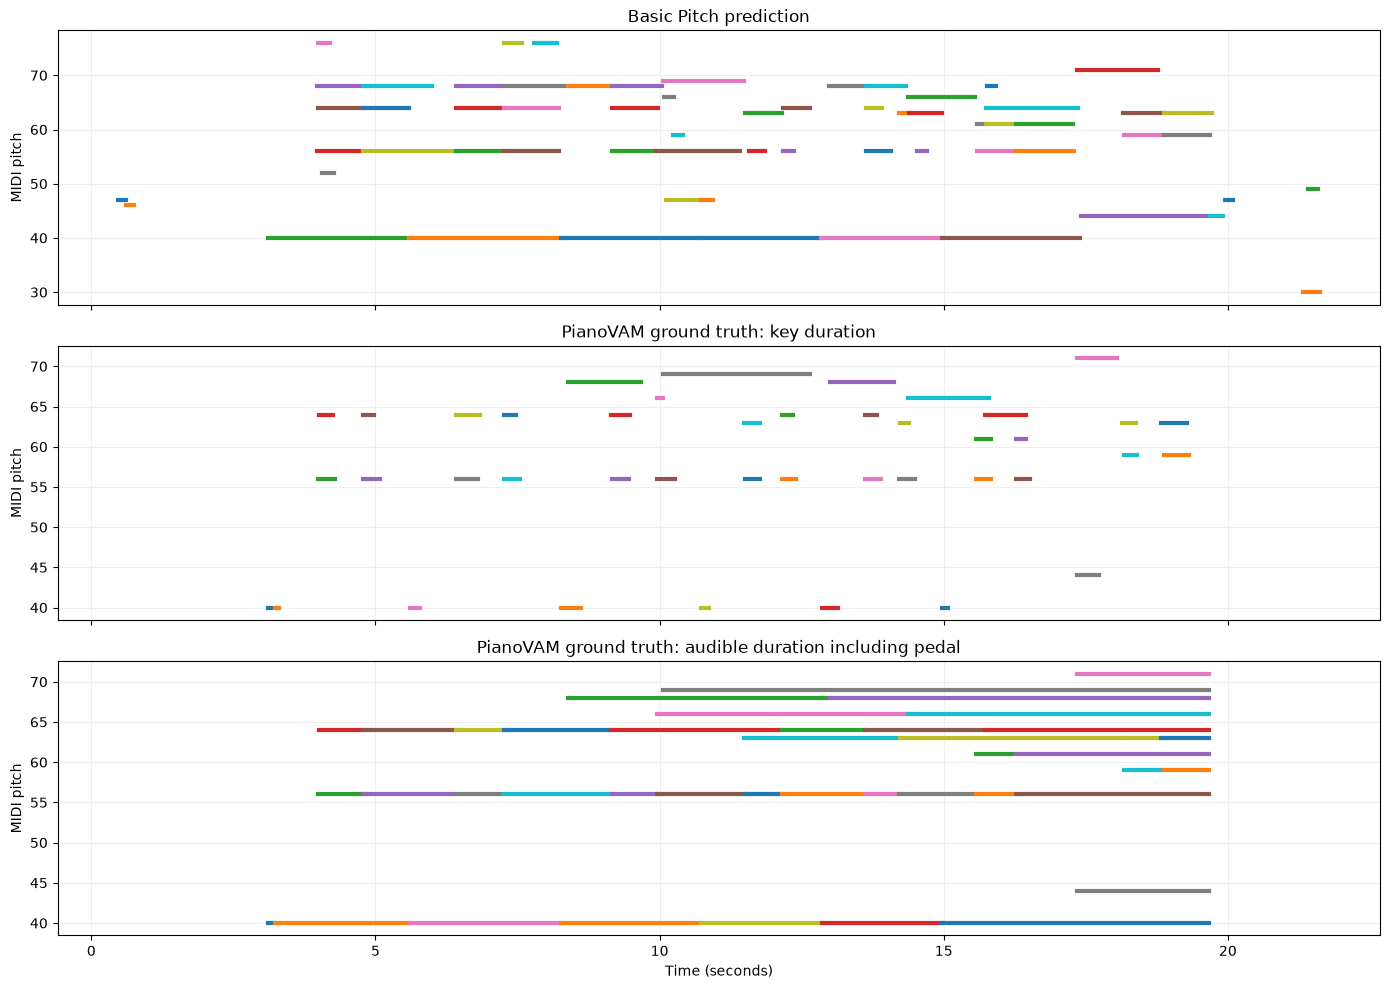

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True
)

for note in predicted_notes:
    axes[0].plot(
        [note["onset"], note["offset"]],
        [note["pitch"], note["pitch"]],
        linewidth=3
    )

axes[0].set_title("Basic Pitch prediction")
axes[0].set_ylabel("MIDI pitch")
axes[0].grid(alpha=0.2)

for note in ground_truth_notes:
    axes[1].plot(
        [note["onset"], note["key_offset"]],
        [note["pitch"], note["pitch"]],
        linewidth=3
    )

axes[1].set_title("PianoVAM ground truth: key duration")
axes[1].set_ylabel("MIDI pitch")
axes[1].grid(alpha=0.2)

for note in ground_truth_notes:
    axes[2].plot(
        [note["onset"], note["frame_offset"]],
        [note["pitch"], note["pitch"]],
        linewidth=3
    )

axes[2].set_title(
    "PianoVAM ground truth: audible duration including pedal"
)
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("MIDI pitch")
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [14]:
def build_compare_midi_input(notes, duration_key):
    """
    Convert a list of note dicts (each with "pitch", "onset", and a chosen
    duration field) into the {"notes": [...]} format expected by
    compare_performance_ED(), which reads exactly "pitch", "start", "duration".

    Args:
        notes: list of note dicts with "pitch", "onset", and duration_key
        duration_key: which field to use as duration, e.g. "duration" for
            predicted notes, or "audible_duration" for ground-truth notes

    Returns:
        dict with a single "notes" key
    """
    converted_notes = []
    for note in notes:
        converted_notes.append({
            "pitch": note["pitch"],
            "start": note["onset"],
            "duration": note[duration_key],
        })
    return {"notes": converted_notes}


# predicted duration comes straight from Basic Pitch's own note offset
response_midi = build_compare_midi_input(predicted_notes, duration_key="duration")

# ground-truth duration uses frame_offset-derived audible_duration, not key_duration,
# for the reason discussed earlier (pedal makes key_offset the wrong reference)
reference_midi = build_compare_midi_input(ground_truth_notes, duration_key="audible_duration")

In [15]:
from evaluation_function.compare_MIDI import compare_performance_ED

CHORD_ONSET_WINDOW = 0.05

single_sample_result = compare_performance_ED(
    response_midi, reference_midi, chord_onset_window=CHORD_ONSET_WINDOW
)

print(single_sample_result.feedback_message)
print(single_sample_result.stats)

Overview: 
Timing: your overall tempo is within an acceptable range. Good job! The timing is about 4% behind the reference in general while notes are held about 70% shorter than than the reference.
There are 3 notes played with the wrong pitch.
There are no missing notes. Great!
There are 11 extra notes played during practice. You may need to adjust your fingering or hand position to avoid extra notes.
Chords: 5/15 correct, 10/15 imperfect (some notes missing or extra), 0/15 completely wrong.

Note Detail:
Extra note played: pitch 47 at t=0.00s 
Extra note played: pitch 52 at t=3.60s 
Extra note played: pitch 76 at t=7.32s 
Extra note played: pitch 59 at t=9.77s 
Extra note played: pitch 63 at t=11.04s 
Extra note played: pitch 63 at t=13.76s 
Extra note played: pitch 71 at t=16.88s 
Extra note played: pitch 44 at t=19.23s 
Extra note played: pitch 47 at t=19.48s 
Extra note played: pitch 30 at t=20.86s 
Extra note played: pitch 49 at t=20.95s 
Note 1: wrong pitch — expected 40, played

Can see that the transcription output has the correct format and can be passed into the existing feedback pipeline successfully. However, can observed from both the pianoroll plot and the feedback that, there seems to be many differences between the transcripted MIDI and ground trunth for this sample. By listening to the transcipted MIDI, ground truth MIDI and original audio, they sound similar in general, but with the following problems: 
- the transcripted MIDI contains some pre-performance non-musical sounds (that's why I include a normalise start time part in the compareMIDI pipeline, cause performers may not start playing as soon as the recording is started)
    - the feedback may report unexpected extra notes, consider adding noise-removal post-processing
- the transcripted MIDI sounds more 'continuous' and 'noisy' than the ground truth, this may be due to the usage of pedal, some sympathetic resonance, piano overtones are recognized as independent notes..
    - the feedback on duration may be mostly affected, may need to modify: maybe use looser threshold? calculate the duration using the (TSV audible offset - Basic Pitch predicted offset) instead of (MIDI key-release offset - Basic Pitch predicted offset)

Now, start applying Basic Pitch the the whole PianoVAM dataset to see how it performs, and optimise it accordingly.

# II. AMT Baseline evaluation using the PianoVAM dataset

### AMT Accuracy Evaluation

Basic Pitch is applied to audio recordings and its predicted MIDI are compared with the MIDI recorded by Disklavier. This measures whether the audio has been converted into an accurate symbolic representation of what was actually played.

Rachel, 2022 used mir_eval [(https://mir-eval.readthedocs.io/latest/)] to compute the following metrics: 
- note-level Fmeasure (F): notes are considered correct if the pitch is within a quarter tone, the onset is within 50 ms, and the offset is within 20% of the note’s duration
- the note-level F-measure-no-offset (Fno): same criterion as F-measure, but ignoring offsets (main measure of overall note estimation accuracy since the definition of offsets is less objective
than onsets)
- frame-level note accuracy (Acc): computed for frames with a hop size of 10 ms. 


reference:

https://colinraffel.com/publications/ismir2014mir_eval.pdf

C.Raffel, B. McFee, E. J. Humphrey, J. Salamon, O. Nieto, D. Liang, and D. P. W. Ellis, “mir_eval: A Transparent Implementation of Common MIR Metrics”, Proceedings of the 15th International Conference on Music Information Retrieval, 2014.

- precision: the proportion of predicted notes that match a reference note;
- recall: the proportion of reference notes recovered by the model;
- F1: the harmonic mean of precision and recall.


In [ ]:
import numpy as np
import mir_eval

def notes_to_mir_eval_arrays(notes, offset_name):
    intervals = np.array(
        [
            [float(note["onset"]), float(note[offset_name])]
            for note in notes
        ],
        dtype=float,
    )

    pitches = np.array(
        [float(note["pitch"]) for note in notes],
        dtype=float,
    )

    if len(intervals) == 0:
        intervals = np.empty((0, 2), dtype=float)

    frequencies = mir_eval.util.midi_to_hz(pitches)
    return intervals, frequencies

visualisation - piano roll

### Downstream impact-on-feedback analysis

effectness on feedback brought by AMT (if any), i.e. investigate how transcription uncertainty affects feedback quality
- e.g. if AMT makes a mistake when recgonizing certain note, it will cause an error in the evaluation

The predicted MIDI is passed into `compare_performance_ED()` pipeline, using the Disklavier MIDI as the reference. Because both files represent the same performance, any missing-note, extra-note, wrong-pitch, timing, duration, or chord feedback produced in this comparison is caused by transcription error rather than by the pianist. 

This provides a task-oriented measure of how AMT errors propagate into educational feedback, hence can help improve the post-processing part accordingly to avoid providing misleading feedback. 


### Qualitative case study - real recordings of student practice

analyse the result on a real recording

# III. Optimisation